<a href="https://colab.research.google.com/github/savinthie/Final_Year_Project_IDP_2024-2025/blob/main/Final_IDP_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing of necessary libraries**

In [1]:
from tensorflow.keras.layers import Layer
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, ReLU, Concatenate, MaxPooling1D,Dropout
from tensorflow.keras.optimizers import Adam
import joblib
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
import xgboost as xgb
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tqdm import tqdm
from google.colab import drive

**Data collection stage**

In [2]:
drive.mount('/content/drive')
original_household_dataset = pd.read_csv('/content/drive/MyDrive/FYP 2024 25/USDataset.csv', header=1)

Mounted at /content/drive


**Data preprocessing stage**

In [3]:
original_household_dataset = original_household_dataset.fillna(0)
original_household_dataset.columns = [col.lower().replace(' ', '').replace('.', '') for col in original_household_dataset.columns]
cols_to_keep = ['stateabv', 'county', 'family', 'housing', 'food', 'transportation',
                'healthcare', 'othernecessities', 'childcare', 'taxes', 'total',
                'median_family_income', 'num_counties_in_st']
household_dataset = original_household_dataset[cols_to_keep].copy()

household_dataset['median_family_income'] = household_dataset['median_family_income'].replace(',', '', regex=True).astype(float)

**Feature engineering stage**

In [4]:
household_dataset['median_family_income'] = household_dataset['median_family_income'].map(lambda x: x/12)#getting the median family income on monthly basis
household_dataset['n_parents'] = household_dataset['family'].str.slice(0, 1).astype(int) # new feature
household_dataset['n_children'] = household_dataset['family'].str.slice(2, 3).astype(int) # new feature
household_dataset['n_members'] = household_dataset['n_parents'] + household_dataset['n_children'] # new feature
household_dataset['financial_stability'] = household_dataset['median_family_income'] / household_dataset['total'] # new feature
household_dataset["per_member_cost"] = household_dataset["total"] / household_dataset["n_members"] # new feature
household_dataset["child_expense_cost"] = household_dataset["per_member_cost"]*household_dataset["n_children"] # new feature
household_dataset["parent_expense_cost"] = household_dataset["per_member_cost"]*household_dataset["n_parents"] # new feature
household_dataset["other_expense_cost"] = household_dataset["total"] - (household_dataset["child_expense_cost"]+household_dataset["parent_expense_cost"]) # new feature
# fixing the 0 child issue
household_dataset["zero_childcare_cost"] = household_dataset['n_children'].map(lambda x: 0 if x < 1 else 1) # new feature

**Feature scaling (An important data handling technique in the Neural networks)**

In [5]:
# Splitting the data
#inputs
X = household_dataset[['total', 'median_family_income', 'num_counties_in_st', 'n_children', 'n_parents', 'n_members']+['per_member_cost','child_expense_cost','parent_expense_cost','other_expense_cost','zero_childcare_cost']].values
# output labels
y_expenses = household_dataset[['housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']].values
# output labels
target_col_list = ['housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']

# Scaling
scaler_X = MinMaxScaler()

# Load the X scaler
# scaler_X = joblib.load('scaler_X.pkl')

X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()

# Load the y scaler
# scaler_y = joblib.load('scaler_y.pkl')
y_exp_scaled = scaler_y.fit_transform(y_expenses)


# Save the X scaler
joblib.dump(scaler_X, 'scaler_X.pkl')

# Save the y scaler
joblib.dump(scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']

In [6]:
# this method is used to avoid the issue in the mape and smape value for the childcare expenses since the childcare expenses consist of 0 value where the smape and mape are sensitive of.
def replace_zeros_with_ones(a, b):
    # Iterate through both lists simultaneously
    for i in range(len(a)):
        # If both value is 0, replace both with 1
        if a[i] == 0 and b[i] == 0:
            a[i] = 1
            b[i] = 1
    return a, b

*The replace_zero_with_one function is used to handle the infinity values in the MAPE and SMAPE metrics in the Childcare expenses since the Childcare expense for the no child is 0*

In [7]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def calculateSmape(y_true, y_pred):
    y_true, y_pred = replace_zeros_with_ones(y_true, y_pred)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_value = np.mean(numerator / denominator) * 100
    return smape_value

In [8]:
# Cross-Validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=100) # 5 folds

# Metrics
def print_metrics(y_true, y_pred, task_name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{task_name} - MSE: {mse:.4f}, R2: {r2:.4f}")

def regr_report(x, y):
    mae = round(mean_absolute_error(x, y), 4)
    r2 = round(r2_score(x, y), 4)
    mse = round(mean_squared_error(x, y), 4)
    rmse = round(np.sqrt(mean_squared_error(x, y)), 4)
    smape_score = calculateSmape(x, y)
    mape= round(mean_absolute_percentage_error(x, y), 4)
    return f'MAE: {mae}, R-Squared: {r2}, RMSE: {rmse}, MSE: {mse} ,SMAPE: {smape_score}, MAPE: {mape}' # evaluation metrics

In [9]:
num_children_col = 3  # 4th position, 0-indexed
childcare_exp_col = target_col_list.index('childcare')  # Replace 'childcare_exp' with the actual target name

**Model selection stage**

*Implementation of the Novel hybrid model*

**1D CNN-MLP Hybrid model**

In [10]:
# L2 regularization strength (you can tune this value)
l2_strength = 0.01

# Hybrid Model Definition
def create_hybrid_model(input_shape, output_shape):
    input_layer = Input(shape=input_shape)
    # CNN part
    x = Conv1D(filters=8, kernel_size=3, padding='same', activation='relu')(input_layer)
    x = Flatten()(x)
    # MLP part
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    # Multiple regression outputs
    output_layers = [Dense(1, activation='linear', name=f'target_{col}')(x) for col in target_col_list]

    household_model = Model(inputs=input_layer, outputs=output_layers)
    return household_model

In [11]:
global X_train_global, X_test_global, X_val_global
global y_train_global, y_test_global, y_val_global

Fold 1/5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 11, 1)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 11, 8)          │             32 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 88)             │              0 │ conv1d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │         11,392 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 64)             │          8,256 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_1[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_1[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0649 - target_childcare_loss: 0.0081 - target_food_loss: 0.0047 - target_healthcare_loss: 0.0121 - target_housing_loss: 0.0054 - target_othernecessities_loss: 0.0056 - target_taxes_loss: 0.0088 - target_transportation_loss: 0.0201 - val_loss: 0.0134 - val_target_childcare_loss: 0.0020 - val_target_food_loss: 5.0919e-04 - val_target_healthcare_loss: 0.0047 - val_target_housing_loss: 0.0013 - val_target_othernecessities_loss: 8.4302e-04 - val_target_taxes_loss: 4.7894e-04 - val_target_transportation_loss: 0.0036
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0133 - target_childcare_loss: 0.0020 - target_food_loss: 5.8727e-04 - target_healthcare_loss: 0.0048 - target_housing_loss: 0.0013 - target_othernecessities_loss: 8.2794e-04 - target_taxes_loss: 4.5974e-04 - target_transportation_loss: 0.0033 - val_loss: 0.0129 - val_target_childcare_loss: 0.0019 - val_target_food_loss: 4.9144e-04 - val_target_healthcare_

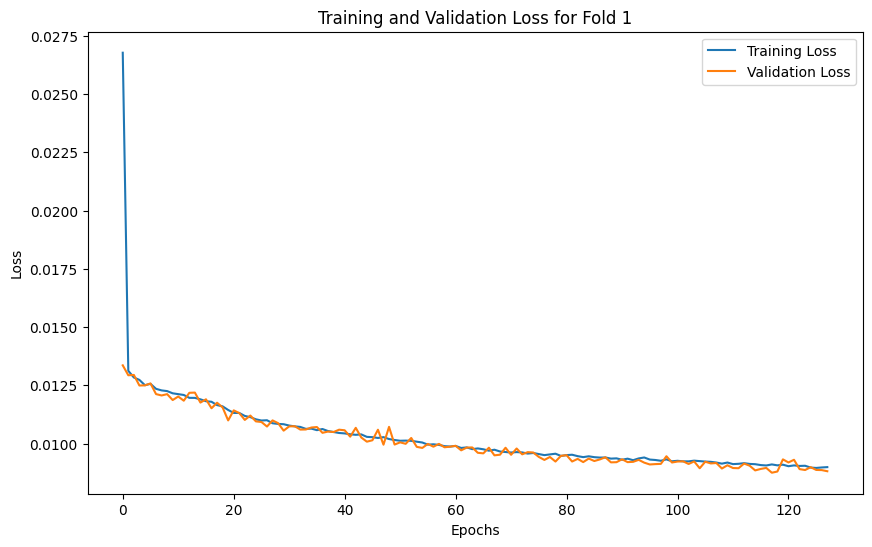

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Model Results for Housing:
Train Data: MAE: 81.291, R-Squared: 0.9076, RMSE: 117.395, MSE: 13781.5794 ,SMAPE: 7.578525108000031, MAPE: 7.6432
Validation Data: MAE: 81.4591, R-Squared: 0.9046, RMSE: 116.491, MSE: 13570.1514 ,SMAPE: 7.660923829878712, MAPE: 7.7534
Test Data: MAE: 84.089, R-Squared: 0.9012, RMSE: 120.7898, MSE: 14590.1871 ,SMAPE: 7.818133987194738, MAPE: 7.926

Model Results for Food:
Train Data: MAE: 42.3228, R-Squared: 0.9669, RMSE: 62.1746, MSE: 3865.6803 ,SMAPE: 4.869177295765815, MAPE: 4.872
Validation Data: MAE: 41.8201, R-Squared: 0.9694, RMSE: 59.1277, MSE: 3496.0902 ,SMAPE: 4.853658422716745, MAPE: 4.8639
Test Data: MAE: 43.4822, R-Squared: 0.961, RMSE: 67.6508, MSE: 4576.631 ,SMAPE: 4.970076851002543, MAPE: 4.9587

Model Results for Transportation:
Train Data: MAE: 93.0002, R-Squared: 0.7208, RMSE: 125.3325, MSE: 15708.237 ,SMAPE: 6.055327383224

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 11, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 11, 8)          │             32 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (None, 88)             │              0 │ conv1d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 128)            │         11,392 │ flatten_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 64)             │          8,256 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_3[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_3[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_3[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1044 - target_childcare_loss: 0.0142 - target_food_loss: 0.0089 - target_healthcare_loss: 0.0156 - target_housing_loss: 0.0060 - target_othernecessities_loss: 0.0101 - target_taxes_loss: 0.0046 - target_transportation_loss: 0.0450 - val_loss: 0.0147 - val_target_childcare_loss: 0.0021 - val_target_food_loss: 5.4132e-04 - val_target_healthcare_loss: 0.0052 - val_target_housing_loss: 0.0016 - val_target_othernecessities_loss: 0.0010 - val_target_taxes_loss: 6.8478e-04 - val_target_transportation_loss: 0.0037
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0140 - target_childcare_loss: 0.0021 - target_food_loss: 6.1571e-04 - target_healthcare_loss: 0.0051 - target_housing_loss: 0.0014 - target_othernecessities_loss: 9.0496e-04 - target_taxes_loss: 5.8317e-04 - target_transportation_loss: 0.0033 - val_loss: 0.0140 - val_target_childcare_loss: 0.0020 - val_target_food_loss: 5.1672e-04 - val_target_healthcare_loss:

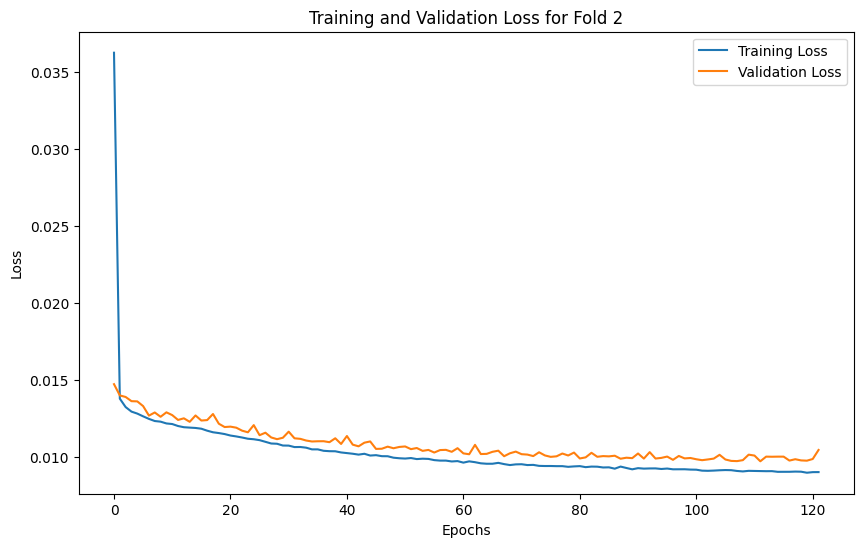

786/786 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing:
Train Data: MAE: 80.189, R-Squared: 0.906, RMSE: 116.3437, MSE: 13535.8563 ,SMAPE: 7.48448657998309, MAPE: 7.5009
Validation Data: MAE: 81.5015, R-Squared: 0.9112, RMSE: 121.0245, MSE: 14646.9228 ,SMAPE: 7.52598970434095, MAPE: 7.5444
Test Data: MAE: 83.3932, R-Squared: 0.9071, RMSE: 124.1186, MSE: 15405.4292 ,SMAPE: 7.604146058236242, MAPE: 7.5909

Model Results for Food:
Train Data: MAE: 43.2708, R-Squared: 0.9655, RMSE: 63.1762, MSE: 3991.236 ,SMAPE: 4.984592107216938, MAPE: 4.9994
Validation Data: MAE: 43.0691, R-Squared: 0.9685, RMSE: 61.9075, MSE: 3832.5431 ,SMAPE: 4.938323142722743, MAPE: 4.9607
Test Data: MAE: 43.7327, R-Squared: 0.9655, RMSE: 63.3466, MSE: 4012.7905 ,SMAPE: 5.049200980285124, MAPE: 5.0716

Model Results for Transportation:
Train Data: MAE: 93.9659, R-Squared: 0.7229, RMSE: 124.9841, MSE: 15621.031 ,SMAPE: 6.113938052

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 11, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 11, 8)          │             32 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_2 (Flatten)       │ (None, 88)             │              0 │ conv1d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 128)            │         11,392 │ flatten_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 64)             │          8,256 │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_5[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_5[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_5[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0713 - target_childcare_loss: 0.0097 - target_food_loss: 0.0192 - target_healthcare_loss: 0.0145 - target_housing_loss: 0.0039 - target_othernecessities_loss: 0.0057 - target_taxes_loss: 0.0073 - target_transportation_loss: 0.0109 - val_loss: 0.0151 - val_target_childcare_loss: 0.0022 - val_target_food_loss: 7.3822e-04 - val_target_healthcare_loss: 0.0056 - val_target_housing_loss: 0.0015 - val_target_othernecessities_loss: 9.3988e-04 - val_target_taxes_loss: 5.8995e-04 - val_target_transportation_loss: 0.0035
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0140 - target_childcare_loss: 0.0022 - target_food_loss: 6.4773e-04 - target_healthcare_loss: 0.0049 - target_housing_loss: 0.0014 - target_othernecessities_loss: 9.5818e-04 - target_taxes_loss: 5.5493e-04 - target_transportation_loss: 0.0034 - val_loss: 0.0140 - val_target_childcare_loss: 0.0024 - val_target_food_loss: 6.2793e-04 - val_target_healthcare_l

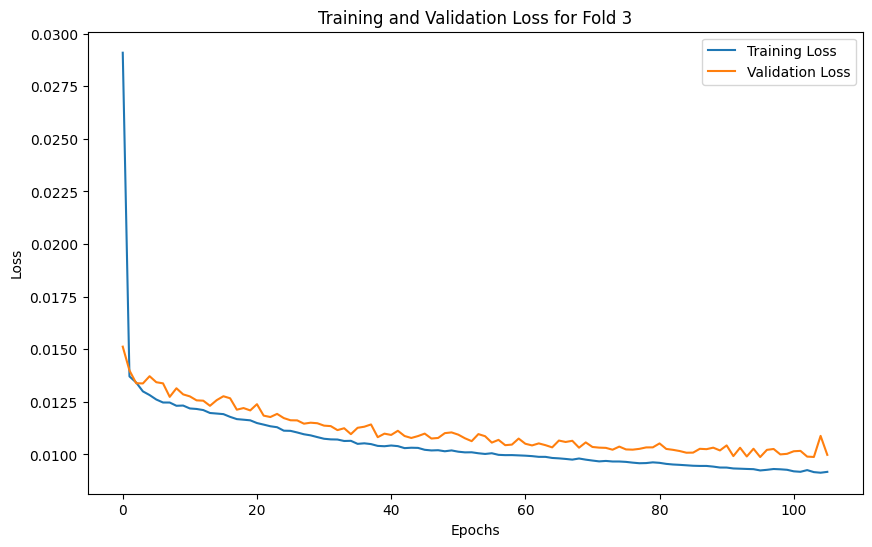

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Model Results for Housing:
Train Data: MAE: 82.187, R-Squared: 0.9064, RMSE: 118.1994, MSE: 13971.1069 ,SMAPE: 7.688193934721803, MAPE: 7.7677
Validation Data: MAE: 86.3305, R-Squared: 0.8954, RMSE: 122.3859, MSE: 14978.3015 ,SMAPE: 8.083757418900037, MAPE: 8.1987
Test Data: MAE: 83.5784, R-Squared: 0.8985, RMSE: 121.582, MSE: 14782.1742 ,SMAPE: 7.75664227014104, MAPE: 7.8561

Model Results for Food:
Train Data: MAE: 42.4022, R-Squared: 0.9663, RMSE: 62.7039, MSE: 3931.7809 ,SMAPE: 4.879226511388459, MAPE: 4.8562
Validation Data: MAE: 44.6767, R-Squared: 0.9611, RMSE: 67.7451, MSE: 4589.4053 ,SMAPE: 5.072756566972673, MAPE: 5.0369
Test Data: MAE: 42.2816, R-Squared: 0.964, RMSE: 63.5653, MSE: 4040.5472 ,SMAPE: 4.843818007333713, MAPE: 4.8265

Model Results for Transportation:
Train Data: MAE: 93.4096, R-Squared: 0.7214, RMSE: 125.7406, MSE: 15810.6907 ,SMAPE: 6.0835286

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 11, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 11, 8)          │             32 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_3 (Flatten)       │ (None, 88)             │              0 │ conv1d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 128)            │         11,392 │ flatten_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 64)             │          8,256 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_7[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_7[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_7[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0653 - target_childcare_loss: 0.0110 - target_food_loss: 0.0052 - target_healthcare_loss: 0.0138 - target_housing_loss: 0.0066 - target_othernecessities_loss: 0.0064 - target_taxes_loss: 0.0048 - target_transportation_loss: 0.0175 - val_loss: 0.0132 - val_target_childcare_loss: 0.0020 - val_target_food_loss: 5.5385e-04 - val_target_healthcare_loss: 0.0048 - val_target_housing_loss: 0.0012 - val_target_othernecessities_loss: 8.4185e-04 - val_target_taxes_loss: 5.1087e-04 - val_target_transportation_loss: 0.0032
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0136 - target_childcare_loss: 0.0020 - target_food_loss: 6.3976e-04 - target_healthcare_loss: 0.0049 - target_housing_loss: 0.0014 - target_othernecessities_loss: 8.7741e-04 - target_taxes_loss: 5.0471e-04 - target_transportation_loss: 0.0034 - val_loss: 0.0129 - val_target_childcare_loss: 0.0019 - val_target_food_loss: 5.0881e-04 - val_target_healthcare_l

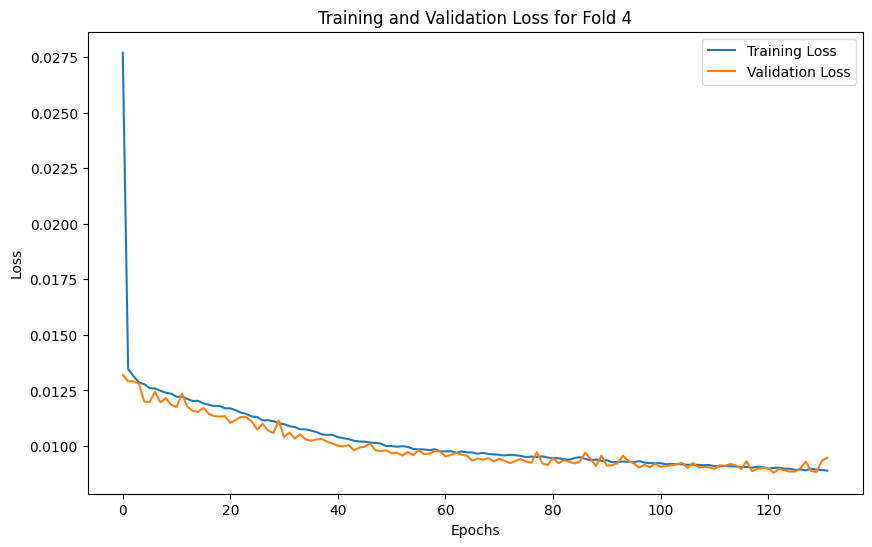

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing:
Train Data: MAE: 80.9509, R-Squared: 0.9073, RMSE: 117.5873, MSE: 13826.767 ,SMAPE: 7.4921679270934325, MAPE: 7.5673
Validation Data: MAE: 81.849, R-Squared: 0.8948, RMSE: 119.431, MSE: 14263.7603 ,SMAPE: 7.642113146251865, MAPE: 7.6762
Test Data: MAE: 85.0296, R-Squared: 0.8986, RMSE: 124.8487, MSE: 15587.1893 ,SMAPE: 7.8308389903121505, MAPE: 7.8909

Model Results for Food:
Train Data: MAE: 42.4507, R-Squared: 0.9665, RMSE: 62.4998, MSE: 3906.2199 ,SMAPE: 4.892930563215728, MAPE: 4.8501
Validation Data: MAE: 42.1955, R-Squared: 0.9692, RMSE: 59.8299, MSE: 3579.6142 ,SMAPE: 4.955364745329835, MAPE: 4.9256
Test Data: MAE: 42.3325, R-Squared: 0.968, RMSE: 60.9528, MSE: 3715.246 ,SMAPE: 4.841851282057828, MAPE: 4.8086

Model Results for Transportation:
Train Data: MAE: 92.3425, R-Squared: 0.728, RMSE: 124.0474, MSE: 15387.7567 ,SMAPE: 6.0122151

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 11, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 11, 8)          │             32 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_4 (Flatten)       │ (None, 88)             │              0 │ conv1d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 128)            │         11,392 │ flatten_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 64)             │          8,256 │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_9[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_9[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_9[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0613 - target_childcare_loss: 0.0081 - target_food_loss: 0.0022 - target_healthcare_loss: 0.0219 - target_housing_loss: 0.0101 - target_othernecessities_loss: 0.0061 - target_taxes_loss: 0.0038 - target_transportation_loss: 0.0093 - val_loss: 0.0139 - val_target_childcare_loss: 0.0020 - val_target_food_loss: 7.2345e-04 - val_target_healthcare_loss: 0.0050 - val_target_housing_loss: 0.0014 - val_target_othernecessities_loss: 8.9610e-04 - val_target_taxes_loss: 5.3512e-04 - val_target_transportation_loss: 0.0032
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0141 - target_childcare_loss: 0.0021 - target_food_loss: 5.8933e-04 - target_healthcare_loss: 0.0051 - target_housing_loss: 0.0014 - target_othernecessities_loss: 9.0545e-04 - target_taxes_loss: 5.1553e-04 - target_transportation_loss: 0.0035 - val_loss: 0.0131 - val_target_childcare_loss: 0.0018 - val_target_food_loss: 6.9286e-04 - val_target_healthcare_l

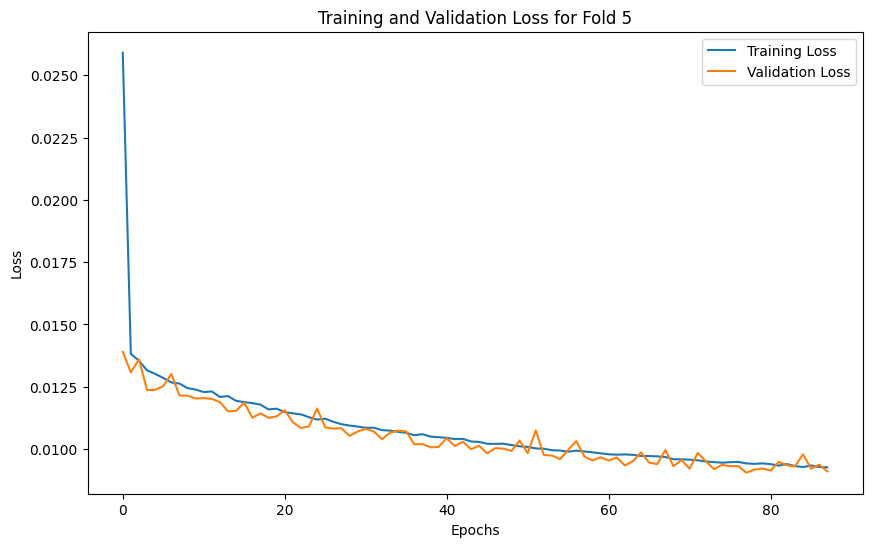

786/786 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing:
Train Data: MAE: 81.0396, R-Squared: 0.9057, RMSE: 118.924, MSE: 14142.9223 ,SMAPE: 7.552814106017937, MAPE: 7.6247
Validation Data: MAE: 81.2777, R-Squared: 0.8954, RMSE: 117.6135, MSE: 13832.9441 ,SMAPE: 7.560366129321393, MAPE: 7.6096
Test Data: MAE: 82.9443, R-Squared: 0.901, RMSE: 122.4297, MSE: 14989.0337 ,SMAPE: 7.719468782505127, MAPE: 7.819

Model Results for Food:
Train Data: MAE: 42.0777, R-Squared: 0.9663, RMSE: 62.7086, MSE: 3932.3624 ,SMAPE: 4.812417193572478, MAPE: 4.7732
Validation Data: MAE: 44.9345, R-Squared: 0.9588, RMSE: 69.2549, MSE: 4796.2434 ,SMAPE: 5.084870356205314, MAPE: 5.0302
Test Data: MAE: 42.8415, R-Squared: 0.966, RMSE: 62.7209, MSE: 3933.9067 ,SMAPE: 4.9269357600510215, MAPE: 4.8764

Model Results for Transportation:
Train Data: MAE: 94.7445, R-Squared: 0.7155, RMSE: 126.9556, MSE: 16117.7155 ,SMAPE: 6.165098

In [12]:
# Cross-Validation with Evaluation
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, num_epochs=200):# 200 iterations
    global X_train_global, X_test_global, X_val_global
    global y_train_global, y_test_global, y_val_global
    fold = 1
    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index] # 80% training

        X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=100) # 50/50 split of remaining 20% for testing and validation

        X_train_global, X_test_global, X_val_global = X_train, X_test, X_val
        y_train_global, y_test_global, y_val_global = y_train, y_test, y_val

        # Reshaping data for CNN
        X_train = X_train[..., np.newaxis]
        X_val = X_val[..., np.newaxis]
        X_test = X_test[..., np.newaxis]

        household_model = create_hybrid_model((X_train.shape[1], 1), y_train.shape[1])
        household_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error') # adams optimizer is used

        household_model.summary()

        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) # early stopping to avoid excess training/overfitting

        # Training
        history=household_model.fit(X_train, [y_train[:, i] for i in range(y_train.shape[1])],
                  validation_data=(X_val, [y_val[:, i] for i in range(y_val.shape[1])]),
                  epochs=num_epochs, batch_size=64, verbose=1, callbacks= [early_stopping])
           # Plot training and validation loss curves for all the 5 folds
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title(f'Training and Validation Loss for Fold {fold}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        # Predictions
        y_train_pred = np.column_stack(household_model.predict(X_train)) #. Prediction on the train set
        y_val_pred = np.column_stack(household_model.predict(X_val))# Prediction on the validation set
        y_test_pred = np.column_stack(household_model.predict(X_test)) #Prediction on test set

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred)
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred) #Inverse transform for test set
        y_test_original = scaler_y.inverse_transform(y_test) #Inverse transform for test set

        # Enforce the rule after predictions for childcare expense
        # The issue is likely caused by X_train having an extra dimension due to[..., np.newaxis].
        # We need to select the original features for the condition
        y_train_pred_original[:, childcare_exp_col] = np.where(
            X_train[:, num_children_col, 0] == 0, 0, y_train_pred_original[:, childcare_exp_col]) #Using X_train[:, num_children_col, 0] instead of X_train[:, num_children_col]

        y_val_pred_original[:, childcare_exp_col] = np.where(
            X_val[:, num_children_col, 0] == 0, 0, y_val_pred_original[:, childcare_exp_col]) #Using X_val[:, num_children_col, 0] instead of X_val[:, num_children_col]

        y_test_pred_original[:, childcare_exp_col] = np.where(
            X_test[:, num_children_col, 0] == 0, 0, y_test_pred_original[:, childcare_exp_col]) #Using X_test[:, num_children_col, 0] instead of X_test[:, num_children_col]

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()}:')
            print('Train Data:', regr_report(y_train_original[:, i], y_train_pred_original[:, i]))#Print metric for train set
            print('Validation Data:', regr_report(y_val_original[:, i], y_val_pred_original[:, i])) #Print metrics for validation set
            print('Test Data:', regr_report(y_test_original[:, i], y_test_pred_original[:, i])) #Print metrics for test set
            print()

        fold += 1 # moving to the next k fold (iteration process)
    return household_model

household_model_combine = cross_val_with_evaluation(X_scaled, y_exp_scaled,kf) # passing the parameters such as the scaled features, targets, and the number of k folds

**XGBoost**

In [13]:
# Cross-Validation with Evaluation for XGBoost
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, num_boost_rounds=4000): # the number of times a tree is fit to the data is 4000
    fold = 1
    childcarelist = []
    childcarelist_pred = []
    for train_index, val_index in kf.split(X_scaled):
        models = []
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        # Split validation and test data
        X_test, X_val, y_test, y_val = train_test_split(
            X_test_val, y_test_val, test_size=0.5, random_state=100 # to avoid different evaluation metric results each time the the model gets trained
        )  # 50/50 split of remaining 20%

        # Train the XGBoost model for each target variable
        # Store predictions for all targets in this fold
        all_y_train_pred = []
        all_y_val_pred = []
        all_y_test_pred = []

        for i in range(y_train.shape[1]):
            dtrain = xgb.DMatrix(X_train, label=y_train[:, i])
            dval = xgb.DMatrix(X_val, label=y_val[:, i])
            dtest = xgb.DMatrix(X_test)

            params = {
                'objective': 'reg:squarederror',
                'eval_metric': 'rmse',
                'learning_rate': 0.01,
                'max_depth': 6,
                'n_estimators': num_boost_rounds
            }

            evals = [(dtrain, 'train'), (dval, 'eval')]
            model = xgb.train(
                params, dtrain, num_boost_rounds, evals, early_stopping_rounds=50, verbose_eval=50
            )
            models.append(model) #Not required here

            # Predictions
            y_train_pred = model.predict(dtrain)
            y_val_pred = model.predict(dval)
            y_test_pred = model.predict(dtest)

            # Append predictions for current target to the list
            all_y_train_pred.append(y_train_pred)
            all_y_val_pred.append(y_val_pred)
            all_y_test_pred.append(y_test_pred)

        # Stack predictions for all targets to get the original shape
        y_train_pred = np.column_stack(all_y_train_pred)
        y_val_pred = np.column_stack(all_y_val_pred)
        y_test_pred = np.column_stack(all_y_test_pred)

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred) #Now y_train_pred has 7 columns matching scaler_y
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)  #Now y_val_pred has 7 columns matching scaler_y
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred) #Now y_test_pred has 7 columns matching scaler_y
        y_test_original = scaler_y.inverse_transform(y_test)


        # Enforce the rule after predictions for childcare expense
        y_train_pred_original[:, childcare_exp_col] = np.where(
            X_train[:, num_children_col] == 0, 0, y_train_pred_original[:, childcare_exp_col])

        y_val_pred_original[:, childcare_exp_col] = np.where(
            X_val[:, num_children_col] == 0, 0, y_val_pred_original[:, childcare_exp_col])

        y_test_pred_original[:, childcare_exp_col] = np.where(
            X_test[:, num_children_col] == 0, 0, y_test_pred_original[:, childcare_exp_col])

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()}:')
            print('Train Data:', regr_report(y_train_original[:, i], y_train_pred_original[:, i]))
            print('Validation Data:', regr_report(y_val_original[:, i], y_val_pred_original[:, i]))
            print('Test Data:', regr_report(y_test_original[:, i], y_test_pred_original[:, i])) #Print metrics for test set
            print()

        fold += 1
    return models

# Cross-Validation Execution
xgb_models = cross_val_with_evaluation(X_scaled, y_exp_scaled, kf)

Fold 1/5


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:723: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:04:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	train-rmse:0.09576	eval-rmse:0.09357
[50]	train-rmse:0.06498	eval-rmse:0.06382
[100]	train-rmse:0.04792	eval-rmse:0.04759
[150]	train-rmse:0.03894	eval-rmse:0.03937
[200]	train-rmse:0.03424	eval-rmse:0.03522
[250]	train-rmse:0.03154	eval-rmse:0.03279
[300]	train-rmse:0.02986	eval-rmse:0.03120
[350]	train-rmse:0.02847	eval-rmse:0.02993
[400]	train-rmse:0.02729	eval-rmse:0.02883
[450]	train-rmse:0.02634	eval-rmse:0.02797
[500]	train-rmse:0.02578	eval-rmse:0.02749
[550]	train-rmse:0.02528	eval-rmse:0.02708
[600]	train-rmse:0.02482	eval-rmse:0.02670
[650]	train-rmse:0.02448	eval-rmse:0.02645
[700]	train-rmse:0.02410	eval-rmse:0.02616
[750]	train-rmse:0.02364	eval-rmse:0.02578
[800]	train-rmse:0.02330	eval-rmse:0.02550
[850]	train-rmse:0.02298	eval-rmse:0.02523
[900]	train-rmse:0.02266	eval-rmse:0.02493
[950]	train-rmse:0.02233	eval-rmse:0.02463
[1000]	train-rmse:0.02201	eval-rmse:0.02431
[1050]	train-rmse:0.02180	eval-rmse:0.02412
[1100]	train-rmse:0.02156	eval-rmse:0.02391
[1150]	trai

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:04:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[50]	train-rmse:0.07255	eval-rmse:0.07138
[100]	train-rmse:0.04744	eval-rmse:0.04623
[150]	train-rmse:0.03361	eval-rmse:0.03239
[200]	train-rmse:0.02653	eval-rmse:0.02541
[250]	train-rmse:0.02301	eval-rmse:0.02213
[300]	train-rmse:0.02126	eval-rmse:0.02061
[350]	train-rmse:0.02031	eval-rmse:0.01991
[400]	train-rmse:0.01966	eval-rmse:0.01947
[450]	train-rmse:0.01921	eval-rmse:0.01918
[500]	train-rmse:0.01879	eval-rmse:0.01891
[550]	train-rmse:0.01844	eval-rmse:0.01869
[600]	train-rmse:0.01817	eval-rmse:0.01853
[650]	train-rmse:0.01786	eval-rmse:0.01831
[700]	train-rmse:0.01754	eval-rmse:0.01812
[750]	train-rmse:0.01726	eval-rmse:0.01797
[800]	train-rmse:0.01705	eval-rmse:0.01786
[850]	train-rmse:0.01683	eval-rmse:0.01773
[900]	train-rmse:0.01661	eval-rmse:0.01763
[950]	train-rmse:0.01643	eval-rmse:0.01754
[1000]	train-rmse:0.01623	eval-rmse:0.01744
[1050]	train-rmse:0.01606	eval-rmse:0.01735
[1100]	train-rmse:0.01590	eval-rmse:0.01728
[1150]	train-rmse:0.01575	eval-rmse:0.01723
[1200]	t

...

[50]	train-rmse:0.07390	eval-rmse:0.07119
[100]	train-rmse:0.05002	eval-rmse:0.04832
[150]	train-rmse:0.03700	eval-rmse:0.03606
[200]	train-rmse:0.03015	eval-rmse:0.02980
[250]	train-rmse:0.02652	eval-rmse:0.02660
[300]	train-rmse:0.02451	eval-rmse:0.02487
[350]	train-rmse:0.02312	eval-rmse:0.02360
[400]	train-rmse:0.02214	eval-rmse:0.02274
[450]	train-rmse:0.02140	eval-rmse:0.02212
[500]	train-rmse:0.02071	eval-rmse:0.02154
[550]	train-rmse:0.01994	eval-rmse:0.02087
[600]	train-rmse:0.01943	eval-rmse:0.02043
[650]	train-rmse:0.01902	eval-rmse:0.02009
[700]	train-rmse:0.01870	eval-rmse:0.01982
[750]	train-rmse:0.01843	eval-rmse:0.01960
[800]	train-rmse:0.01818	eval-rmse:0.01941
[850]	train-rmse:0.01799	eval-rmse:0.01927
[900]	train-rmse:0.01777	eval-rmse:0.01911
[950]	train-rmse:0.01754	eval-rmse:0.01895
[1000]	train-rmse:0.01735	eval-rmse:0.01882
[1050]	train-rmse:0.01720	eval-rmse:0.01872
[1100]	train-rmse:0.01703	eval-rmse:0.01861
[1150]	train-rmse:0.01685	eval-rmse:0.01850
[1200]	t

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:17:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[50]	train-rmse:0.09960	eval-rmse:0.09560
[100]	train-rmse:0.06871	eval-rmse:0.06631
[150]	train-rmse:0.05199	eval-rmse:0.05081
[200]	train-rmse:0.04292	eval-rmse:0.04256
[250]	train-rmse:0.03791	eval-rmse:0.03808
[300]	train-rmse:0.03486	eval-rmse:0.03535
[350]	train-rmse:0.03277	eval-rmse:0.03356
[400]	train-rmse:0.03141	eval-rmse:0.03243
[450]	train-rmse:0.03053	eval-rmse:0.03168
[500]	train-rmse:0.02982	eval-rmse:0.03106
[550]	train-rmse:0.02907	eval-rmse:0.03044
[600]	train-rmse:0.02864	eval-rmse:0.03007
[650]	train-rmse:0.02821	eval-rmse:0.02971
[700]	train-rmse:0.02777	eval-rmse:0.02935
[750]	train-rmse:0.02737	eval-rmse:0.02905
[800]	train-rmse:0.02702	eval-rmse:0.02879
[850]	train-rmse:0.02672	eval-rmse:0.02855
[900]	train-rmse:0.02645	eval-rmse:0.02835
[950]	train-rmse:0.02624	eval-rmse:0.02820
[1000]	train-rmse:0.02604	eval-rmse:0.02808
[1050]	train-rmse:0.02579	eval-rmse:0.02791
[1100]	train-rmse:0.02555	eval-rmse:0.02776
[1150]	train-rmse:0.02534	eval-rmse:0.02765
[1200]	t

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:18:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[50]	train-rmse:0.05980	eval-rmse:0.05650
[100]	train-rmse:0.03976	eval-rmse:0.03803
[150]	train-rmse:0.02828	eval-rmse:0.02761
[200]	train-rmse:0.02175	eval-rmse:0.02173
[250]	train-rmse:0.01796	eval-rmse:0.01829
[300]	train-rmse:0.01562	eval-rmse:0.01617
[350]	train-rmse:0.01393	eval-rmse:0.01454
[400]	train-rmse:0.01271	eval-rmse:0.01339
[450]	train-rmse:0.01165	eval-rmse:0.01230
[500]	train-rmse:0.01075	eval-rmse:0.01138
[550]	train-rmse:0.00992	eval-rmse:0.01050
[600]	train-rmse:0.00925	eval-rmse:0.00979
[650]	train-rmse:0.00871	eval-rmse:0.00923
[700]	train-rmse:0.00816	eval-rmse:0.00863
[750]	train-rmse:0.00782	eval-rmse:0.00826
[800]	train-rmse:0.00752	eval-rmse:0.00795
[850]	train-rmse:0.00731	eval-rmse:0.00772
[900]	train-rmse:0.00710	eval-rmse:0.00751
[950]	train-rmse:0.00693	eval-rmse:0.00734
[1000]	train-rmse:0.00680	eval-rmse:0.00721
[1050]	train-rmse:0.00670	eval-rmse:0.00712
[1100]	train-rmse:0.00659	eval-rmse:0.00702
[1150]	train-rmse:0.00650	eval-rmse:0.00694
[1200]	t

In [14]:
def createAdditinalFeatures(X_scaled, xgb_models):
  #initialize a list to store the predicitions
    new_y_exp_scaled = []
    # Iterate over the model and generate the prediction
    for model in tqdm(xgb_models):
        predict_vals = model.predict(xgb.DMatrix(X_scaled))
        new_y_exp_scaled.append(predict_vals)

    new_y_exp_scaled_val = np.array(new_y_exp_scaled) # convert the prediction into a numpy array
    new_y_exp_scaled_val_transp = new_y_exp_scaled_val.T # transposing the predictions to make them concatenate with the original values
    a = X_scaled
    b = new_y_exp_scaled_val_transp
    results = []
    for f,t in zip(a,b):
        results.append(list(f)+list(t))

    additional_features =  np.array(results)
    return additional_features

In [15]:
additional_features = createAdditinalFeatures(X_scaled, xgb_models) # New 7 additional features were created from the XGBoost model

100%|██████████| 7/7 [00:23<00:00,  3.31s/it]


**Combined model**

In [16]:
# Cross-Validation with Evaluation
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, num_epochs=200):
    fold = 1
    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=100) # 50/50 split of remaining 20%

        # Reshaping data for CNN
        X_train = X_train[..., np.newaxis]
        X_val = X_val[..., np.newaxis]
        X_test = X_test[..., np.newaxis]

        model = create_hybrid_model((X_train.shape[1], 1), y_train.shape[1])
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.summary()

        # Training
        model.fit(X_train, [y_train[:, i] for i in range(y_train.shape[1])],
                  validation_data=(X_val, [y_val[:, i] for i in range(y_val.shape[1])]),
                  epochs=num_epochs, batch_size=64, verbose=1, callbacks=[early_stopping])

        # Predictions
        y_train_pred = np.column_stack(model.predict(X_train))
        y_val_pred = np.column_stack(model.predict(X_val))
        y_test_pred = np.column_stack(model.predict(X_test)) #Prediction on test set

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred)
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred) #Inverse transform for test set
        y_test_original = scaler_y.inverse_transform(y_test) #Inverse transform for test set

        # Enforce the rule after predictions for childcare expense
        # The issue is likely caused by X_train having an extra dimension due to[..., np.newaxis].
        # We need to select the original features for the condition
        y_train_pred_original[:, childcare_exp_col] = np.where(
            X_train[:, num_children_col, 0] == 0, 0, y_train_pred_original[:, childcare_exp_col]) #Using X_train[:, num_children_col, 0] instead of X_train[:, num_children_col]

        y_val_pred_original[:, childcare_exp_col] = np.where(
            X_val[:, num_children_col, 0] == 0, 0, y_val_pred_original[:, childcare_exp_col]) #Using X_val[:, num_children_col, 0] instead of X_val[:, num_children_col]

        y_test_pred_original[:, childcare_exp_col] = np.where(
            X_test[:, num_children_col, 0] == 0, 0, y_test_pred_original[:, childcare_exp_col]) #Using X_test[:, num_children_col, 0] instead of X_test[:, num_children_col]

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()}:')
            print('Train Data:', regr_report(y_train_original[:, i], y_train_pred_original[:, i]))
            print('Validation Data:', regr_report(y_val_original[:, i], y_val_pred_original[:, i]))
            print('Test Data:', regr_report(y_test_original[:, i], y_test_pred_original[:, i])) #Print metrics for test set
            print()

        fold += 1
        return model # Return the trained model
combined_model = cross_val_with_evaluation(additional_features, y_exp_scaled, kf) # the total number of inputs should be 18 ()
combined_model.save_weights("model_expenses.weights.h5")

Fold 1/5


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_5 (Conv1D)         │ (None, 18, 8)          │             32 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_5 (Flatten)       │ (None, 144)            │              0 │ conv1d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 128)            │         18,560 │ flatten_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 64)             │          8,256 │ dense_10[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_11[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_11[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_11[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.1028 - target_childcare_loss: 0.0136 - target_food_loss: 0.0093 - target_healthcare_loss: 0.0170 - target_housing_loss: 0.0081 - target_othernecessities_loss: 0.0162 - target_taxes_loss: 0.0051 - target_transportation_loss: 0.0335 - val_loss: 0.0038 - val_target_childcare_loss: 4.4734e-04 - val_target_food_loss: 2.9438e-04 - val_target_healthcare_loss: 7.2481e-04 - val_target_housing_loss: 3.5849e-04 - val_target_othernecessities_loss: 2.4422e-04 - val_target_taxes_loss: 1.3929e-04 - val_target_transportation_loss: 0.0015
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0038 - target_childcare_loss: 5.0534e-04 - target_food_loss: 3.4147e-04 - target_healthcare_loss: 8.1141e-04 - target_housing_loss: 3.9861e-04 - target_othernecessities_loss: 2.3943e-04 - target_taxes_loss: 1.0712e-04 - target_transportation_loss: 0.0014 - val_loss: 0.0026 - val_target_childcare_loss: 3.8002e-04 - val_target_food_loss: 1.8958e-

**Model testing**

In [36]:
# Load the scalers
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')


def get_prediction(combined_model, input_data, scaler_X, scaler_y, xgb_models, num_children_col, childcare_exp_col):

    # Step 1: Create new features
    input_data_with_features = createFeatures(input_data.copy())

    # Step 2: Select relevant features
    X = input_data_with_features[['total', 'median_family_income', 'num_counties_in_st', 'n_children',
                                  'n_parents', 'n_members', 'per_member_cost', 'child_expense_cost',
                                  'parent_expense_cost', 'other_expense_cost','zero_childcare_cost']].values

    # Step 3: Scale the input data using the fitted scaler_X
    input_data_scaled = scaler_X.transform(X)

    # Step 4: Create Additional Features using XGBoost models
    additional_features = createAdditinalFeatures(input_data_scaled, xgb_models)

    # Reshape for the CNN layer (add the extra dimension)
    additional_features = additional_features[..., np.newaxis]  # Reshape additional_features

    # Step 5: Make predictions using the trained model
    # We need to unpack the predictions from the model output
    # Then, we can stack those into a single output array.
    input_data_pred = combined_model.predict(additional_features) # Predict on additional_features
    input_data_pred = np.column_stack(input_data_pred)

    # Step 6: Inverse transform the predictions to return them to the original scale
    input_data_pred_original = scaler_y.inverse_transform(input_data_pred)

    # Step 7: Enforce the rule that if there are no children, childcare cost is 0
    input_data_pred_original[:, childcare_exp_col] = np.where(
        input_data_with_features['n_children'].values == 0, 0, input_data_pred_original[:, childcare_exp_col]
    )

    return input_data_pred_original


def createFeatures(input_data):

    # Edge case testing (ADDITIONS)
    input_data["n_members"] = input_data["n_children"] + input_data["n_parents"]
    print("\nAltered Data (with corrected n_members):")
    print(input_data)
    # Step 1: Create additional features
    input_data["per_member_cost"] = input_data["total"] / input_data["n_members"]
    input_data["child_expense_cost"] = input_data["per_member_cost"] * input_data["n_children"]
    input_data["parent_expense_cost"] = input_data["per_member_cost"] * input_data["n_parents"]
    input_data["other_expense_cost"] = input_data["total"] - (input_data["child_expense_cost"] + input_data["parent_expense_cost"])

    # Step 2: Create binary column for whether there are children (0 if no children, 1 if there are children)
    input_data["zero_childcare_cost"] = input_data['n_children'].map(lambda x: 0 if x < 1 else 1)

    return input_data

def createAdditinalFeatures(X_scaled, xgb_models):
    #initialize a list to store the predicitions
    new_y_exp_scaled = []
    # Iterate over the model and generate the prediction
    for model in tqdm(xgb_models):
        predict_vals = model.predict(xgb.DMatrix(X_scaled))
        new_y_exp_scaled.append(predict_vals)

    new_y_exp_scaled_val = np.array(new_y_exp_scaled) # convert the prediction into a numpy array
    new_y_exp_scaled_val_transp = new_y_exp_scaled_val.T # transposing the predictions to make them concatenate with the original values
    a = X_scaled
    b = new_y_exp_scaled_val_transp
    results = []
    for f,t in zip(a,b):
        results.append(list(f)+list(t))

    additional_features =  np.array(results)
    return additional_features

# Example of input data to test predictions
input_data = pd.DataFrame(
    [[4850, 4938.42, 254, 1, 1, 3]],
    columns=['total', 'median_family_income', 'num_counties_in_st', 'n_children', 'n_parents', 'n_members']
)

print("\nUser inserted data: ")
print(input_data)

# Assuming `model_combine` is your trained model
input_data_pred_original = get_prediction(combined_model, input_data, scaler_X, scaler_y, xgb_models, num_children_col=3, childcare_exp_col=5)
print (input_data_pred_original)

# Print predictions
target_col_list = ['housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']
for i, prediction in enumerate(input_data_pred_original[0]):
    print(f"{target_col_list[i]}: {prediction:.2f}")


User inserted data: 
   total  median_family_income  num_counties_in_st  n_children  n_parents   
0   4850               4938.42                 254           1          1  \

   n_members  
0          3  

Altered Data (with corrected n_members):
   total  median_family_income  num_counties_in_st  n_children  n_parents   
0   4850               4938.42                 254           1          1  \

   n_members  
0          2  


100%|██████████| 7/7 [00:00<00:00, 106.33it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[ 873.4716   439.47125 1392.2666   738.54645  465.51685  541.15295
   466.38788]]
housing: 873.47
food: 439.47
transportation: 1392.27
healthcare: 738.55
othernecessities: 465.52
childcare: 541.15
taxes: 466.39


**TabNet Regressor with XAI**

**Importing necessary libraries**

In [18]:
!pip install lime
!pip install dice-ml
!pip install pytorch_tabnet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c136fcf8fd76f1f059148ca502a1fb23c69879406e4d079a7fc8a190304e62d9
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 86.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
xarray 2025.1.1 requir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00


**Data preprocessing**

In [19]:
from sklearn.model_selection import train_test_split
y_expenses = household_dataset[['median_family_income','housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']]
household_income_sufficiency = household_dataset[['financial_stability']].values

scaler_y_stability = MinMaxScaler()
household_income_sufficiency = scaler_y_stability.fit_transform(household_income_sufficiency)


# 80/10/10 split for TabNet
X_train_tabnet, X_rem, y_exp_train_tabnet, y_exp_rem, y_stab_train_tabnet, y_stab_rem = train_test_split(
    X, y_expenses, household_income_sufficiency, test_size=0.2, random_state=100)

X_test_tabnet, X_val_tabnet, y_exp_test_tabnet, y_exp_val_tabnet, y_stab_test_tabnet, y_stab_val_tabnet = train_test_split(
    X_rem, y_exp_rem, y_stab_rem, test_size=0.5, random_state=100)

**Model training**

In [20]:
# TabNet Model for Financial Stability Prediction
from pytorch_tabnet.tab_model import TabNetRegressor
tabnet_stab = TabNetRegressor()
tabnet_stab.fit(
    y_exp_train_tabnet.values, y_stab_train_tabnet.reshape(-1, 1),
    eval_set=[(y_exp_val_tabnet.values, y_stab_val_tabnet.reshape(-1, 1)), (y_exp_test_tabnet.values, y_stab_test_tabnet.reshape(-1, 1))],
    max_epochs=120,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0
)

tabnet_stab.save_model("tabnet_stability.pth")

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.22506 | val_0_mse: 8.50439 | val_1_mse: 8.31914 |  0:00:01s
epoch 1  | loss: 0.01357 | val_0_mse: 0.12391 | val_1_mse: 0.1093  |  0:00:02s
epoch 2  | loss: 0.00644 | val_0_mse: 0.02493 | val_1_mse: 0.02596 |  0:00:03s
epoch 3  | loss: 0.00472 | val_0_mse: 0.01961 | val_1_mse: 0.02069 |  0:00:05s
epoch 4  | loss: 0.00411 | val_0_mse: 0.00757 | val_1_mse: 0.00748 |  0:00:06s
epoch 5  | loss: 0.00344 | val_0_mse: 0.0038  | val_1_mse: 0.00432 |  0:00:07s
epoch 6  | loss: 0.00308 | val_0_mse: 0.00255 | val_1_mse: 0.00305 |  0:00:08s
epoch 7  | loss: 0.00279 | val_0_mse: 0.00204 | val_1_mse: 0.00224 |  0:00:10s
epoch 8  | loss: 0.00262 | val_0_mse: 0.00183 | val_1_mse: 0.0021  |  0:00:12s
epoch 9  | loss: 0.0025  | val_0_mse: 0.00154 | val_1_mse: 0.00164 |  0:00:14s
epoch 10 | loss: 0.00234 | val_0_mse: 0.00143 | val_1_mse: 0.00147 |  0:00:15s
epoch 11 | loss: 0.00222 | val_0_mse: 0.00125 | val_1_mse: 0.00133 |  0:00:16s
epoch 12 | loss: 0.00215 | val_0_mse: 0.00131 | val_

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at tabnet_stability.pth.zip


'tabnet_stability.pth.zip'

**Model evaluation**

In [21]:
y_stab_pred_test = tabnet_stab.predict(y_exp_test_tabnet.values)

# Evaluation Function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}



# Evaluate Results
stability_results = evaluate_model(y_stab_test_tabnet.reshape(-1, 1), y_stab_pred_test)

print("Test evaluation for the tabnetregressor:", stability_results)

Test evaluation for the tabnetregressor: {'MAE': 0.008639132749981168, 'MSE': 0.00014644166459088038, 'RMSE': 0.012101308383430296, 'R2': 0.9886366031890087, 'MAPE': 3.494648847952131}


**Test the predictions**

In [22]:
# Rescale predictions back to original scale
y_stab_pred_test_rescaled = scaler_y_stability.inverse_transform(y_stab_pred_test)
y_stab_test_rescaled = scaler_y_stability.inverse_transform(y_stab_test_tabnet)

# Print Predictions and Actual Values
print("Predicted Financial Stability (Test Set):", y_stab_pred_test_rescaled.flatten())
print("Actual Financial Stability (Test Set):", y_stab_test_rescaled.flatten())

Predicted Financial Stability (Test Set): [1.0927097  0.7663303  0.6545936  ... 1.594643   0.40896857 0.5855472 ]
Actual Financial Stability (Test Set): [1.04653772 0.82891257 0.67483068 ... 1.55485167 0.39389516 0.58967623]


**XAI Technique 1 : LIME**

In [23]:
# LIME for Explainability
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=y_exp_train_tabnet.values,
    feature_names=y_exp_train_tabnet.columns.tolist(),
    class_names=y_exp_train_tabnet.columns.tolist(),
    mode='regression'
)

data_row = [5227.250000,864, 584, 1339, 791, 513,0,661]

data_row = np.array(data_row) # This line is added to convert the list into a numpy array
exp = explainer.explain_instance(
    data_row=data_row,  # Use 1D data here
    predict_fn=tabnet_stab.predict
)


# Display Explanation
print("\nLIME Explanation:")


# # Plot Explanation
exp.show_in_notebook(show_table=True)


LIME Explanation:


**XAI Technique 2: Counterfactual Explanation**

In [24]:
counterfactual_input_cols = ['median_family_income','housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes','financial_stability']

In [25]:
y_exp_test_tabnet

/usr/local/lib/python3.11/dist-packages/google/colab/_interactive_table_hint_button.py:178: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  df_html=dataframe._repr_html_(),  # pylint: disable=protected-access


,median_family_income,housing,food,transportation,healthcare,othernecessities,childcare,taxes
11365,4896.750000,704,587,1219,1081,457,0,630
24745,3656.333333,661,640,1271,883,461,0,495
9849,6144.333333,1077,1363,1803,1770,864,1140,1089
4662,3690.583333,1111,725,1723,948,650,935,951
27282,5419.666667,1301,645,1583,930,689,1297,745
...,...,...,...,...,...,...,...,...
7845,5227.250000,864,584,1339,791,513,0,661
20958,8112.500000,1413,1360,1693,1488,982,1778,1212
27050,5031.500000,636,293,1115,443,329,0,420
11457,3103.500000,1054,949,1673,1662,709,908,923


In [26]:
new_test_with_indicator= y_exp_test_tabnet.copy()
new_test_with_indicator["financial_stability"] = y_stab_test_tabnet

In [27]:
new_test_with_indicator

/usr/local/lib/python3.11/dist-packages/google/colab/_interactive_table_hint_button.py:178: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  df_html=dataframe._repr_html_(),  # pylint: disable=protected-access


,median_family_income,housing,food,transportation,healthcare,othernecessities,childcare,taxes,financial_stability
11365,4896.750000,704,587,1219,1081,457,0,630,0.324365
24745,3656.333333,661,640,1271,883,461,0,495,0.256914
9849,6144.333333,1077,1363,1803,1770,864,1140,1089,0.209158
4662,3690.583333,1111,725,1723,948,650,935,951,0.162388
27282,5419.666667,1301,645,1583,930,689,1297,745,0.233627
...,...,...,...,...,...,...,...,...,...
7845,5227.250000,864,584,1339,791,513,0,661,0.340938
20958,8112.500000,1413,1360,1693,1488,982,1778,1212,0.253314
27050,5031.500000,636,293,1115,443,329,0,420,0.481912
11457,3103.500000,1054,949,1673,1662,709,908,923,0.122084


In [28]:
continuous_features=counterfactual_input_cols
outcome_name='financial_stability'

query_instance = pd.DataFrame(
              [data_row],
              columns=counterfactual_input_cols[:-1]
        )

In [29]:
from dice_ml import Data, Model as Modeldice
import dice_ml

In [30]:
# Initialize DiCE for Counterfactual Explanations
data_dice = dice_ml.Data(
    dataframe=new_test_with_indicator,
    continuous_features=y_exp_test_tabnet.columns.tolist(),
    outcome_name='financial_stability'
)


# Wrap the TabNet Stability Model for DiCE
class TabNetWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, input_data):
        input_data = np.array(input_data)
        return self.model.predict(input_data)

dice_model = Modeldice(model=TabNetWrapper(tabnet_stab), backend="sklearn",  model_type='regressor')

# Generate Counterfactuals
# query_instance = y_exp_test_tabnet.iloc[[0]][y_exp_train_tabnet.columns.tolist()]
counterfactuals = dice_ml.Dice(data_dice, dice_model, method="random")

# Generate 3 diverse counterfactuals
cf = counterfactuals.generate_counterfactuals(query_instance,
                                              total_CFs=3,
                                              desired_range=[0.2, 6.0])  # Desired stability range

# Display Counterfactuals
print("\nCounterfactual Explanations:")
cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  5.66it/s]


Counterfactual Explanations:
Query instance (original outcome : 0.0)



/usr/local/lib/python3.11/dist-packages/google/colab/_interactive_table_hint_button.py:178: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  df_html=dataframe._repr_html_(),  # pylint: disable=protected-access
/usr/local/lib/python3.11/dist-packages/google/colab/_interactive_table_hint_button.py:178: FutureWarning: RangeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  df_html=dataframe._repr_html_(),  # pylint: disable=protected-access


,median_family_income,housing,food,transportation,healthcare,othernecessities,childcare,taxes,financial_stability
0,5227.25,864.0,584.0,1339.0,791.0,513.0,0.0,661.0,0.0



Diverse Counterfactual set (new outcome: [0.6, 1.0])


/usr/local/lib/python3.11/dist-packages/google/colab/_interactive_table_hint_button.py:178: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  df_html=dataframe._repr_html_(),  # pylint: disable=protected-access
/usr/local/lib/python3.11/dist-packages/google/colab/_interactive_table_hint_button.py:178: FutureWarning: RangeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  df_html=dataframe._repr_html_(),  # pylint: disable=protected-access


,median_family_income,housing,food,transportation,healthcare,othernecessities,childcare,taxes,financial_stability
0,13976.9856,-,409.0,-,-,-,-,-,0.748487114906311
1,13068.51,-,-,-,-,-,-,-,0.7054803967475891
2,12934.433,-,-,-,-,-,1186.0,-,0.6748244762420654
